In [1]:
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph, END, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage

load_dotenv()  # Load environment variables from .env file

C:\Users\Ashutosh Pandey\AppData\Local\Temp\ipykernel_35288\2351858839.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


True

In [2]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)

In [3]:
# search tools
search_tool = DuckDuckGoSearchRun(region="us-en")

In [4]:
@tool
def calculate_tool(first_num: float, second_num: float, operation: str)-> dict:
    """
    perform the arithametic operation on the two numbers
    operations allowed are add, sub, multi, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "multi":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "ZeroDivisionError please try with number"}
            result = first_num/second_num
        else:
            return {"error": "Invalid operation please try with add, sub, multi, div"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}


In [5]:
#making a tool list 
tools = [calculate_tool, search_tool]

# binding the tool making llm aware
llm_with_tools = llm.bind_tools(tools)

In [6]:
#creating the chat state
class chatstate(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages ]

In [7]:
# creatign the chat node
def chatnode(state: chatstate):
    """LLM node that may answer or request a tool call"""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# our tool node
tool_node = ToolNode(tools)

In [8]:
#graph structure
graph = StateGraph(chatstate)
graph.add_node("chatnode", chatnode)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chatnode")
graph.add_conditional_edges("chatnode", tools_condition)
# minor improvement
graph.add_edge("tools", "chatnode")

In [9]:
chatbot = graph.compile()


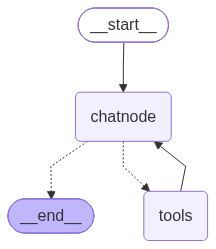

In [10]:
from IPython.display import Image
Image(chatbot.get_graph().draw_mermaid_png())

In [11]:
# lets call the chatbot
while True:
    user_input = input("TypeHere:" )
    print("user: ", user_input)
    if user_input.strip().lower() == "exit":
        break
    response = chatbot.invoke({"messages":[HumanMessage(content=user_input)]})
    print("chatbot: ", response['messages'][-1].content)

user:  can you calculate 456789*1234567
chatbot:  The result of the multiplication is 563,936,625,363.
user:  hi
chatbot:  I'm happy to chat with you, but I don't see a specific question or task that you need help with. Is there something I can assist you with or would you like to just have a conversation?
user:  exit
